In [22]:
from prepare_quarterly import prepare_quarterly_boroughs
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_quarter = prepare_quarterly_boroughs()

/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2/src/stream_1/quarterly/prepare_quarterly.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw['quarter'] = pd.cut(raw['MonthTwelve'], bins=[0,3,6,9,12], labels=[1,2,3,4])
/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2/src/stream_1/quarterly/prepare_quarterly.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw['LA_Name'] = raw['LA_2023'].map(dc.get_data_dict()['LA_2023']['

In [4]:
df_quarter.shape

(768, 7)

In [5]:
df_quarter['t'] = df_quarter.groupby('LA_Name').cumcount()

In [13]:
df_quarter[['LA_Name', 't']]

,LA_Name,t
0,Barking and Dagenham,0
1,Barking and Dagenham,1
2,Barking and Dagenham,2
3,Barking and Dagenham,3
4,Barking and Dagenham,4
...,...,...
787,Westminster,19
788,Westminster,20
789,Westminster,21
790,Westminster,22


In [14]:
train = df_quarter[df_quarter['t'] < 20]
test = df_quarter[df_quarter['t'] >= 20]

In [41]:
df_covid = df_quarter.groupby('t')['MEMS7_ALL'].mean().reset_index()
df_covid['label'] = ['16','','','','18','','','','19','','','','20','','','','21','','','','22','','','']

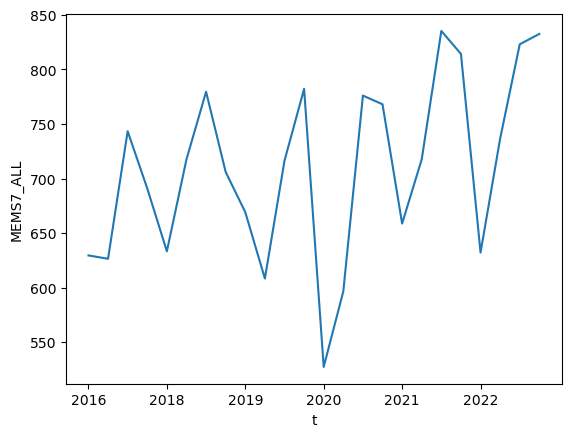

In [46]:

sns.lineplot(data=df_covid, x='t', y='MEMS7_ALL')
plt.xticks(ticks=[0,4,8,12,16,20], labels=['2016','2018','2019','2020','2021','2022'])
plt.show()
